# Stopword Removal Analysis


## Import


In [21]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from omegaconf import OmegaConf

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

config = OmegaConf.load(PROJECT_ROOT / "src" / "configs" / "experiment.yaml")
results_dir = PROJECT_ROOT / config.paths.results_dir
images_dir = PROJECT_ROOT / config.paths.images_dir

pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)
sns.set_theme(style="whitegrid")

## Load Experiment Metrics

Purpose: read `reports/results/metrics.csv`, sort the experiment rows, and display the main metrics for all model and stopword-ratio combinations.

Expected output: a 15-row table with accuracy, macro F1, weighted F1, cross-validation score, and best hyperparameters.


In [12]:
metrics = pd.read_csv(results_dir / "metrics.csv")
metrics = metrics.sort_values(["stopword_ratio", "model"]).reset_index(drop=True)

metric_columns = [
    "stopword_ratio",
    "model",
    "accuracy",
    "macro_f1",
    "weighted_f1",
    "cv_best_score",
    "best_params",
]

display(metrics[metric_columns])

,stopword_ratio,model,accuracy,macro_f1,weighted_f1,cv_best_score,best_params
0,0.0,logistic_regression,0.8798,0.8775,0.8801,0.9053,"{""C"": 10.0, ""class_weight"": ""balanced""}"
1,0.0,naive_bayes,0.9136,0.9108,0.9138,0.9238,"{""alpha"": 0.1}"
2,0.0,random_forest,0.8424,0.8372,0.8420,0.8416,"{""max_depth"": null, ""min_samples_leaf"": 2}"
3,0.2,logistic_regression,0.8846,0.8824,0.8851,0.9072,"{""C"": 10.0, ""class_weight"": ""balanced""}"
4,0.2,naive_bayes,0.9136,0.9110,0.9138,0.9284,"{""alpha"": 0.1}"
5,0.2,random_forest,0.8493,0.8458,0.8496,0.8386,"{""max_depth"": null, ""min_samples_leaf"": 2}"
6,0.5,logistic_regression,0.8832,0.8811,0.8838,0.9088,"{""C"": 10.0, ""class_weight"": ""balanced""}"
7,0.5,naive_bayes,0.9143,0.9117,0.9144,0.9280,"{""alpha"": 0.1}"
8,0.5,random_forest,0.8521,0.8497,0.8532,0.8498,"{""max_depth"": null, ""min_samples_leaf"": 2}"
9,0.8,logistic_regression,0.8867,0.8843,0.8872,0.9136,"{""C"": 10.0, ""class_weight"": ""balanced""}"


## Baseline Model Ranking

Purpose: isolate the baseline setting where `stopword_ratio = 0.0`. This keeps all stopwords and lets us compare the three models before any stopword removal.

Expected output: a table ranking the baseline models by macro F1-score, plus a printed sentence naming the best baseline model.


In [13]:
baseline_metrics = (
    metrics[metrics["stopword_ratio"] == 0.0]
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

display(baseline_metrics[metric_columns[1:]])

best_baseline = baseline_metrics.iloc[0]
print(
    "Best baseline model: "
    f"{best_baseline['model']} | "
    f"accuracy={best_baseline['accuracy']:.4f} | "
    f"macro_f1={best_baseline['macro_f1']:.4f} | "
    f"best_params={best_baseline['best_params']}"
)

,model,accuracy,macro_f1,weighted_f1,cv_best_score,best_params
0,naive_bayes,0.9136,0.9108,0.9138,0.9238,"{""alpha"": 0.1}"
1,logistic_regression,0.8798,0.8775,0.8801,0.9053,"{""C"": 10.0, ""class_weight"": ""balanced""}"
2,random_forest,0.8424,0.8372,0.8420,0.8416,"{""max_depth"": null, ""min_samples_leaf"": 2}"


Best baseline model: naive_bayes | accuracy=0.9136 | macro_f1=0.9108 | best_params={"alpha": 0.1}


## Baseline Per-Class Performance

Purpose: load the saved `classification_report.json` for the best baseline model and convert per-class precision, recall, F1-score, and support into a readable table.

Expected output: a per-class table showing which class is easiest and hardest to classify when no stopwords are removed.


In [14]:
def report_path(model_name: str, ratio: float) -> Path:
    run_id = f"tfidf_{model_name}_stopwords_{ratio:.1f}"
    return results_dir / f"{run_id}_classification_report.json"


def load_report(model_name: str, ratio: float) -> dict:
    return json.loads(report_path(model_name, ratio).read_text(encoding="utf-8"))


def class_f1_table(model_name: str, ratio: float) -> pd.DataFrame:
    report = load_report(model_name, ratio)
    rows = [
        {
            "class": class_name,
            "precision": report[class_name]["precision"],
            "recall": report[class_name]["recall"],
            "f1_score": report[class_name]["f1-score"],
            "support": report[class_name]["support"],
        }
        for class_name in config.categories
    ]
    return pd.DataFrame(rows).sort_values("f1_score", ascending=False)


baseline_class_f1 = class_f1_table(best_baseline["model"], 0.0)
display(baseline_class_f1)

easiest_class = baseline_class_f1.iloc[0]
hardest_class = baseline_class_f1.iloc[-1]
print(f"Easiest baseline class: {easiest_class['class']} | f1={easiest_class['f1_score']:.4f}")
print(f"Hardest baseline class: {hardest_class['class']} | f1={hardest_class['f1_score']:.4f}")

,class,precision,recall,f1_score,support
1,rec.sport.hockey,0.9661,0.9587,0.9624,387.0
2,comp.graphics,0.9423,0.9373,0.9398,383.0
0,sci.space,0.8797,0.8750,0.8773,376.0
3,talk.politics.misc,0.8539,0.8738,0.8637,301.0


Easiest baseline class: rec.sport.hockey | f1=0.9624
Hardest baseline class: talk.politics.misc | f1=0.8637


## Macro F1 Trend Charts

Purpose: draw one line chart per model to show how macro F1-score changes across stopword ratios.

Expected output: three line charts, one each for Naive Bayes, Logistic Regression, and Random Forest.


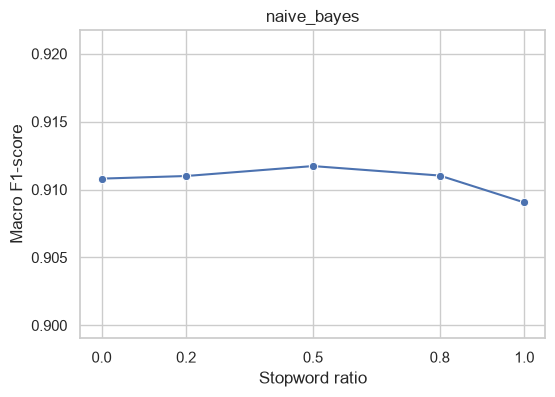

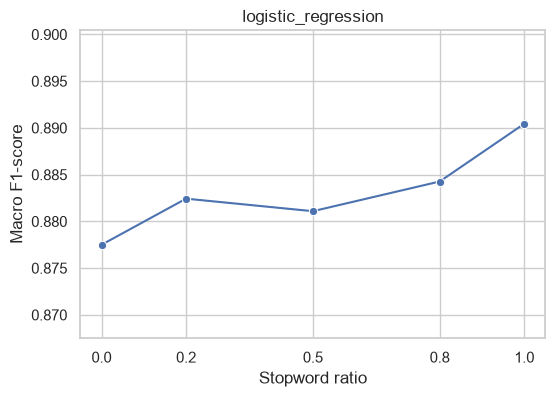

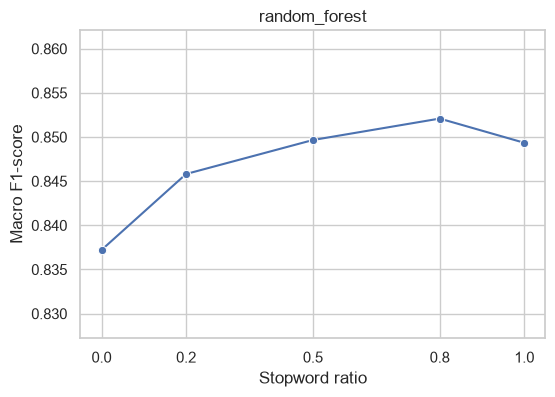

In [ ]:
def set_zoomed_y_axis(ax, values, padding=0.02):
    lower = max(0, values.min() - padding)
    upper = min(1, values.max() + padding)
    ax.set_ylim(lower, upper)


for model_name in config.model_names:
    model_metrics = metrics[metrics["model"] == model_name]

    fig, ax = plt.subplots(figsize=(6, 4))
    sns.lineplot(
        data=model_metrics,
        x="stopword_ratio",
        y="macro_f1",
        marker="o",
        ax=ax,
    )
    ax.set_title(f"{model_name}")
    ax.set_xlabel("Stopword ratio")
    ax.set_ylabel("Macro F1-score")
    ax.set_xticks(list(config.stopword_ratios))
    set_zoomed_y_axis(ax, model_metrics["macro_f1"], padding=0.01)
    plt.show()

## Baseline Delta and Best Stopword Ratio

Purpose: compare every stopword ratio against the baseline ratio `0.0`, then compute the average performance of each ratio across all three models.

Expected output: one table with `macro_f1_delta` for each model and ratio, one summary table ranked by mean macro F1, and printed lines identifying the best ratio and whether full removal is better than partial removal.


In [16]:
baseline_scores = metrics[metrics["stopword_ratio"] == 0.0][["model", "macro_f1"]].rename(
    columns={"macro_f1": "baseline_macro_f1"}
)

ratio_comparison = metrics.merge(baseline_scores, on="model")
ratio_comparison["macro_f1_delta"] = (
    ratio_comparison["macro_f1"] - ratio_comparison["baseline_macro_f1"]
)

display(
    ratio_comparison[
        ["model", "stopword_ratio", "macro_f1", "baseline_macro_f1", "macro_f1_delta"]
    ].sort_values(["model", "stopword_ratio"])
)

ratio_summary = (
    metrics.groupby("stopword_ratio", as_index=False)
    .agg(mean_macro_f1=("macro_f1", "mean"), mean_weighted_f1=("weighted_f1", "mean"))
    .sort_values("mean_macro_f1", ascending=False)
)

display(ratio_summary)

best_ratio = ratio_summary.iloc[0]
full_removal = ratio_summary[ratio_summary["stopword_ratio"] == 1.0].iloc[0]
best_partial = ratio_summary[ratio_summary["stopword_ratio"] < 1.0].iloc[0]

print(
    f"Best average ratio: {best_ratio['stopword_ratio']} | mean_macro_f1={best_ratio['mean_macro_f1']:.4f}"
)
print(
    "Full removal vs best partial removal: "
    f"1.0={full_removal['mean_macro_f1']:.4f}, "
    f"best_partial={best_partial['mean_macro_f1']:.4f}"
)

,model,stopword_ratio,macro_f1,baseline_macro_f1,macro_f1_delta
0,logistic_regression,0.0,0.8775,0.8775,0.0000
3,logistic_regression,0.2,0.8824,0.8775,0.0049
6,logistic_regression,0.5,0.8811,0.8775,0.0036
9,logistic_regression,0.8,0.8843,0.8775,0.0068
12,logistic_regression,1.0,0.8904,0.8775,0.0129
1,naive_bayes,0.0,0.9108,0.9108,0.0000
4,naive_bayes,0.2,0.9110,0.9108,0.0002
7,naive_bayes,0.5,0.9117,0.9108,0.0009
10,naive_bayes,0.8,0.9110,0.9108,0.0002
13,naive_bayes,1.0,0.9090,0.9108,-0.0018


,stopword_ratio,mean_macro_f1,mean_weighted_f1
4,1.0,0.8829,0.8854
3,0.8,0.8825,0.8853
2,0.5,0.8808,0.8838
1,0.2,0.8797,0.8828
0,0.0,0.8752,0.8786


Best average ratio: 1.0 | mean_macro_f1=0.8829
Full removal vs best partial removal: 1.0=0.8829, best_partial=0.8825


## Model Comparison and Stability

Purpose: summarize each model across all stopword ratios using mean macro F1, standard deviation, maximum macro F1, and the best ratio for that model.

Expected output: a model-level summary table and printed answers for the best average model, the most stable model, Random Forest performance, and whether Logistic Regression is the best model.


In [22]:
model_summary = metrics.groupby("model", as_index=False).agg(
    mean_macro_f1=("macro_f1", "mean"),
    std_macro_f1=("macro_f1", "std"),
    max_macro_f1=("macro_f1", "max"),
    mean_weighted_f1=("weighted_f1", "mean"),
)

best_rows = metrics.loc[
    metrics.groupby("model")["macro_f1"].idxmax(),
    ["model", "stopword_ratio", "macro_f1", "best_params"],
].rename(
    columns={
        "stopword_ratio": "best_ratio",
        "macro_f1": "best_macro_f1",
        "best_params": "best_params_at_best_ratio",
    }
)

model_summary = model_summary.merge(best_rows, on="model")
model_summary = model_summary.sort_values("mean_macro_f1", ascending=False).reset_index(drop=True)

display(model_summary)

best_mean_model = model_summary.iloc[0]
most_stable_model = model_summary.sort_values("std_macro_f1").iloc[0]
rf_row = model_summary[model_summary["model"] == "random_forest"].iloc[0]
lr_row = model_summary[model_summary["model"] == "logistic_regression"].iloc[0]

print(
    f"Highest average macro F1 model: {best_mean_model['model']} | mean={best_mean_model['mean_macro_f1']:.4f}"
)
print(
    f"Most stable model: {most_stable_model['model']} | std={most_stable_model['std_macro_f1']:.4f}"
)
print(f"Random Forest mean macro F1: {rf_row['mean_macro_f1']:.4f}")
print(f"Logistic Regression mean macro F1: {lr_row['mean_macro_f1']:.4f}")

,model,mean_macro_f1,std_macro_f1,max_macro_f1,mean_weighted_f1,best_ratio,best_macro_f1,best_params_at_best_ratio
0,naive_bayes,0.9107,0.0010,0.9117,0.9134,0.5,0.9117,"{""alpha"": 0.1}"
1,logistic_regression,0.8831,0.0048,0.8904,0.8858,1.0,0.8904,"{""C"": 10.0, ""class_weight"": null}"
2,random_forest,0.8468,0.0058,0.8521,0.8504,0.8,0.8521,"{""max_depth"": null, ""min_samples_leaf"": 2}"


Highest average macro F1 model: naive_bayes | mean=0.9107
Most stable model: naive_bayes | std=0.0010
Random Forest mean macro F1: 0.8468
Logistic Regression mean macro F1: 0.8831


## Per-Class F1 Trend for the Best Model

Purpose: focus only on the best model by average macro F1 and inspect how each class changes as stopword removal increases.

Expected output: a per-class F1 table, a line chart by class, a delta table versus ratio `0.0`, and two ranked tables showing classes with the largest improvement or decrease.


class,comp.graphics,rec.sport.hockey,sci.space,talk.politics.misc
stopword_ratio,,,,
0.0,0.9398,0.9624,0.8773,0.8637
0.2,0.9398,0.9610,0.8762,0.8670
0.5,0.9398,0.9573,0.8805,0.8693
0.8,0.9372,0.9561,0.8826,0.8683
1.0,0.9323,0.9562,0.8760,0.8717


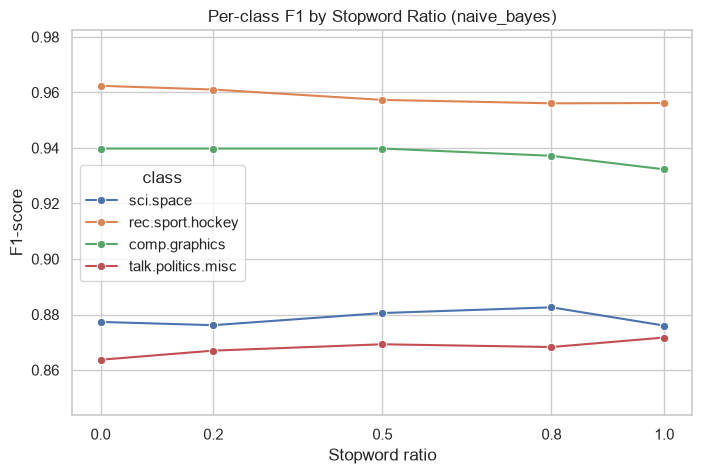

class,comp.graphics,rec.sport.hockey,sci.space,talk.politics.misc
stopword_ratio,,,,
0.0,0.0000,0.0000,0.0000,0.0000
0.2,0.0000,-0.0013,-0.0012,0.0033
0.5,0.0000,-0.0051,0.0032,0.0056
0.8,-0.0026,-0.0063,0.0053,0.0046
1.0,-0.0075,-0.0062,-0.0013,0.0080


Classes with the largest F1 improvement:


,max_f1_delta
class,
talk.politics.misc,0.0080
sci.space,0.0053
comp.graphics,0.0000
rec.sport.hockey,-0.0013


Classes with the largest F1 decrease:


,min_f1_delta
class,
comp.graphics,-0.0075
rec.sport.hockey,-0.0063
sci.space,-0.0013
talk.politics.misc,0.0033


In [18]:
best_model_name = best_mean_model["model"]

per_class_rows = []
for ratio in config.stopword_ratios:
    report = load_report(best_model_name, ratio)
    for class_name in config.categories:
        per_class_rows.append(
            {
                "model": best_model_name,
                "stopword_ratio": ratio,
                "class": class_name,
                "f1_score": report[class_name]["f1-score"],
                "precision": report[class_name]["precision"],
                "recall": report[class_name]["recall"],
            }
        )

per_class_f1 = pd.DataFrame(per_class_rows)
per_class_table = per_class_f1.pivot(
    index="stopword_ratio",
    columns="class",
    values="f1_score",
)

display(per_class_table)

fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(
    data=per_class_f1,
    x="stopword_ratio",
    y="f1_score",
    hue="class",
    marker="o",
    ax=ax,
)
ax.set_title(f"Per-class F1 by Stopword Ratio ({best_model_name})")
ax.set_xlabel("Stopword ratio")
ax.set_ylabel("F1-score")
ax.set_xticks(list(config.stopword_ratios))
set_zoomed_y_axis(ax, per_class_f1["f1_score"], padding=0.02)
plt.show()

class_delta = per_class_table.subtract(per_class_table.loc[0.0], axis="columns")
display(class_delta)

benefit_classes = class_delta.drop(index=0.0).max().sort_values(ascending=False)
decrease_classes = class_delta.drop(index=0.0).min().sort_values()

print("Classes with the largest F1 improvement:")
display(benefit_classes.to_frame("max_f1_delta"))
print("Classes with the largest F1 decrease:")
display(decrease_classes.to_frame("min_f1_delta"))

## Confusion Matrix Summary

Purpose: read the saved confusion matrix CSV files for the best model, remove the diagonal correct predictions, and find the most common class confusions at each stopword ratio.

Expected output: a summary table of total confusion counts, a table of the top confused class pairs, and a printed comparison between ratios `0.0` and `1.0`.


In [19]:
def matrix_path(model_name: str, ratio: float) -> Path:
    run_id = f"tfidf_{model_name}_stopwords_{ratio:.1f}"
    return results_dir / f"{run_id}_confusion_matrix.csv"


def load_matrix(model_name: str, ratio: float) -> pd.DataFrame:
    return pd.read_csv(matrix_path(model_name, ratio), index_col=0)


confusion_rows = []
top_confusion_rows = []

for ratio in config.stopword_ratios:
    matrix = load_matrix(best_model_name, ratio)
    off_diagonal = matrix.copy()

    for class_name in off_diagonal.index:
        off_diagonal.loc[class_name, class_name] = 0

    total_confusions = int(off_diagonal.to_numpy().sum())
    stacked = off_diagonal.stack().reset_index()
    stacked.columns = ["actual", "predicted", "count"]
    stacked = stacked[stacked["count"] > 0].sort_values("count", ascending=False)

    strongest_pair = stacked.iloc[0]
    confusion_rows.append(
        {
            "stopword_ratio": ratio,
            "total_confusions": total_confusions,
            "most_confused_actual": strongest_pair["actual"],
            "most_confused_predicted": strongest_pair["predicted"],
            "most_confused_count": int(strongest_pair["count"]),
        }
    )

    top_confusions = stacked.head(5).copy()
    top_confusions["stopword_ratio"] = ratio
    top_confusion_rows.append(top_confusions)

confusion_summary = pd.DataFrame(confusion_rows)
top_confusions = pd.concat(top_confusion_rows, ignore_index=True)

display(confusion_summary)
display(top_confusions[["stopword_ratio", "actual", "predicted", "count"]])

baseline_confusions = confusion_summary[confusion_summary["stopword_ratio"] == 0.0].iloc[0]
high_ratio_confusions = confusion_summary[confusion_summary["stopword_ratio"] == 1.0].iloc[0]

print(
    "Total confusion at ratio 0.0 vs 1.0: "
    f"{baseline_confusions['total_confusions']} vs {high_ratio_confusions['total_confusions']}"
)

,stopword_ratio,total_confusions,most_confused_actual,most_confused_predicted,most_confused_count
0,0.0,125,sci.space,talk.politics.misc,29
1,0.2,125,sci.space,talk.politics.misc,29
2,0.5,124,sci.space,talk.politics.misc,29
3,0.8,125,sci.space,talk.politics.misc,29
4,1.0,128,sci.space,talk.politics.misc,28


,stopword_ratio,actual,predicted,count
0,0.0,sci.space,talk.politics.misc,29
1,0.0,talk.politics.misc,sci.space,27
2,0.0,sci.space,comp.graphics,15
3,0.0,comp.graphics,sci.space,14
4,0.0,rec.sport.hockey,talk.politics.misc,9
5,0.2,sci.space,talk.politics.misc,29
6,0.2,talk.politics.misc,sci.space,26
7,0.2,comp.graphics,sci.space,16
8,0.2,sci.space,comp.graphics,15
9,0.2,rec.sport.hockey,talk.politics.misc,10


Total confusion at ratio 0.0 vs 1.0: 125 vs 128
